# **Post-Treatement of the simulaiton for the Tsanfleuron glacier**
The aim of this notebook is to import the different simulations of the Tsanfleuron glacier and calculate the volumes returns by the different methods.

## **Input :**
* MPS simulation set run with considering the ti as hard conditionning data
* MPS simulation set run without considering the ti as hard conditionning data
* GRF simulation
* Kriging estimation

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages
import georasters as gr
exec(open('../functions/03_indice_calculation_functions.py').read())

In [182]:
def mean_simu(simu_set, mask):
    '''
    Return the mean simulation extracted.
    '''
    
    mean_simu = np.nanmean(simu_set,axis=0)
    mean_simu = extract(mean_simu, mask)
    mean_simu = cut_extend(mean_simu)
    
    return mean_simu

In [183]:
def volume_extract(simu_set, dem, mask, sx=2, sy=2):
    '''
    Compute the mean volume and volume distribution.
    '''
    
    simu_ext = []
    for simu in simu_set:
        simu_ext.append(extract(simu, mask))
        
    volumes = []
    for simu in simu_ext:
        volumes.append(np.nansum(dem-simu)*sx*sy)
        
    mean_volume = np.mean(volumes)
    
    return volumes, mean_volume, 

In [184]:
def extract(simu, mask):
    '''
    Exctract the zone regarding a mask.
    '''
    
    simuOut = np.full((simu.shape[0],simu.shape[1]),np.nan)
    simu[mask!=1] = np.nan
    
    return simu

In [185]:
def cut_extend(simu):
    '''
    Re-cut the extend.
    '''
    
    simu_out = np.full((1200,1400),np.nan)
    simu_out[:,:] = simu[:1200,:1400]
    
    return simu_out

## Import the simulations

### MPS

In [186]:
path_output_tsanfleuron_mps  = '../simulation_outputs/simulation_set_00/'
simulation_name = os.listdir(path_output_tsanfleuron_mps)

In [187]:
simulation_name

['simulation_tsanfleuron_data_trend.pickle']

In [188]:
with open(path_output_tsanfleuron_mps+simulation_name[0],'rb') as d:
    dem, trend_cut, simu_sets_mps, mask_box_ti, position = pickle.load(d)

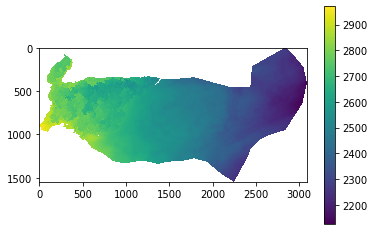

In [189]:
plt.imshow(simu_sets_mps[0][0])
plt.colorbar()
plt.show()

### DEM

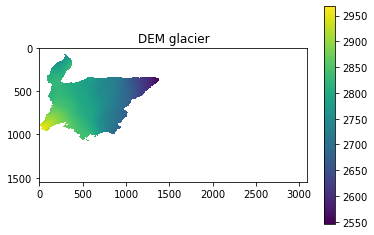

In [190]:
plt.imshow(dem)
plt.title('DEM glacier')
plt.colorbar()
plt.show()

### Mask

In [191]:
mask_ts = np.copy(dem)
mask_ts[~np.isnan(dem)]=1
mask_ts[np.isnan(dem)]=0

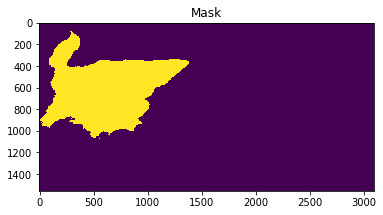

In [192]:
plt.imshow(mask_ts)
plt.title('Mask')
plt.show()

## We calcule the mean volume of the simulation and extract the mean simulation

In [193]:
volumes_distri_mps, mean_volume_mps = volume_extract(simu_sets_mps[0], trueMNT, mask_ts)

In [194]:
print('The mean volume of the MPS simulation is : {} Mm³'.format(str(mean_volume_mps/1e6)))

The mean volume of the MPS simulation is : 151.42919775621917 Mm³


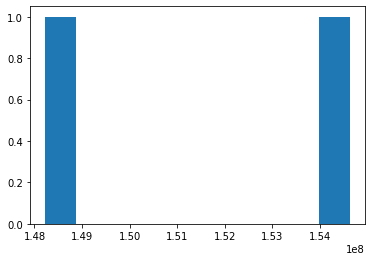

In [195]:
plt.hist(volumes_distri_mps)
plt.show()

In [196]:
mean_simu_mps = mean_simu(simu_sets_mps[0],mask_ts)

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  


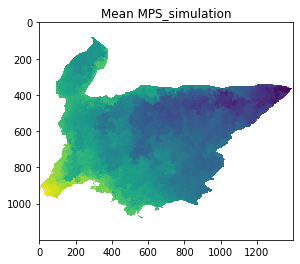

In [197]:
plt.imshow(mean_simu_mps)
plt.title('Mean MPS_simulation')
plt.show()

### SGS

In [ ]:
def add_trend(simu_set, mask, hd):
    #GPR data
    x_gpr   = hd.cell_x.values
    y_gpr   = hd.cell_y.values
    alt_gpr = hd.alt.values
    x_gpr.shape, y_gpr.shape, alt_gpr.shape
    
    #Polynomial regression
    from sklearn.preprocessing import PolynomialFeatures
    X_fit = np.c_[x_gpr,y_gpr]
    polynomial_features = PolynomialFeatures(degree=2)
    X_poly = polynomial_features.fit_transform(X_fit)
    
    #Linear regression
    from sklearn.linear_model import LinearRegression
    model = LinearRegression()
    model.fit(X_poly, alt_gpr)
    
    #Predict the trend of the simulation output
    simu_ext = []
    for simu in simu_set:
        simu[mask!=1] == np.nan
        simu_ext.append(simu)
    
    simu_trend = []        
    x     = np.arange(0,simu.shape[1],1)
    y     = np.arange(0,simu.shape[0],1)
    X,Y   = np.meshgrid(x,y)
    for simu in simu_ext:
        val  = simu.flatten()
        X    = X.flatten()
        X    = X[~np.isnan(simu)]
        Y    = Y.flatten()
        Y    = Y[~np.isnan(simu)]
        val  = val[~np.isnan(simu)]
        X_pred = np.c_[X,Y]
        Z_poly = model.predict(X_poly)
    #####
    #To Finish
    #####
    

In [133]:
path_output_tsanfleuron_sgs  = '../simulation_outputs/simulation_set_00/'
simulation_name = os.listdir(path_output_tsanfleuron_sgs)

In [120]:
simulation_name

['simulation_tsanfleuron_data_trend.pickle']

In [121]:
with open(path_output_tsanfleuron_sgs+simulation_name[0],'rb') as d:
    dem, trend_cut, simu_sets_sgs, mask_box_ti, position = pickle.load(d)

## We calcule the mean volume of the simulation and extract the mean simulation

In [127]:
volumes_distri_sgs, mean_volume_sgs = volume_extract(simu_sets_sgs[0], trueMNT, mask_ts)

In [128]:
print('The mean volume of the SGS simulation is : {} Mm³'.format(str(mean_volume_sgs/1e6)))

The mean volume of the simulation is : 151.42919775621917 Mm³


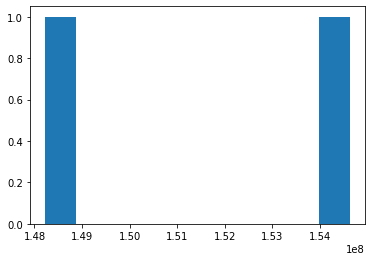

In [129]:
plt.hist(volumes_distri_sgs)
plt.show()

In [130]:
mean_simu_sgs = mean_simu(simu_sets_sgs[0],mask_ts)

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  


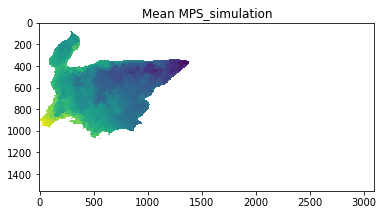

In [131]:
plt.imshow(mean_simu_sgs)
plt.title('Mean MPS_simulation')
plt.show()

### Krig

In [133]:
path_output_tsanfleuron_krig  = '../simulation_outputs/simulation_set_00/'
simulation_name = os.listdir(path_output_tsanfleuron_krig)

In [120]:
simulation_name

['simulation_tsanfleuron_data_trend.pickle']

In [121]:
with open(path_output_tsanfleuron_krig+simulation_name[0],'rb') as d:
    dem, trend_cut, simu_sets_krig, mask_box_ti, position = pickle.load(d)

## We calcule the mean volume of the simulation and extract the mean simulation

In [127]:
volumes_distri_krig, mean_volume_krig = volume_extract(simu_sets_krig[0], trueMNT, mask_ts)

In [128]:
print('The volume of the krig simulation is : {} Mm³'.format(str(mean_volume_krig/1e6)))

The mean volume of the simulation is : 151.42919775621917 Mm³


In [130]:
mean_simu_krig = mean_simu(simu_sets_sgs[0],mask_ts)

/home/valentin/anaconda3/envs/Deese/lib/python3.6/site-packages/ipykernel_launcher.py:6: RuntimeWarning: Mean of empty slice
  


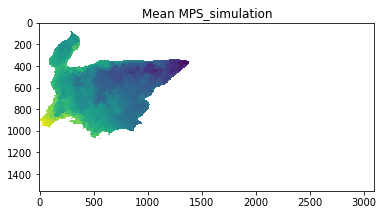

In [131]:
plt.imshow(mean_simu_krig)
plt.title('Mean MPS_simulation')
plt.show()

## Plot the result

NameError: name 'mean_simu_sgs' is not defined

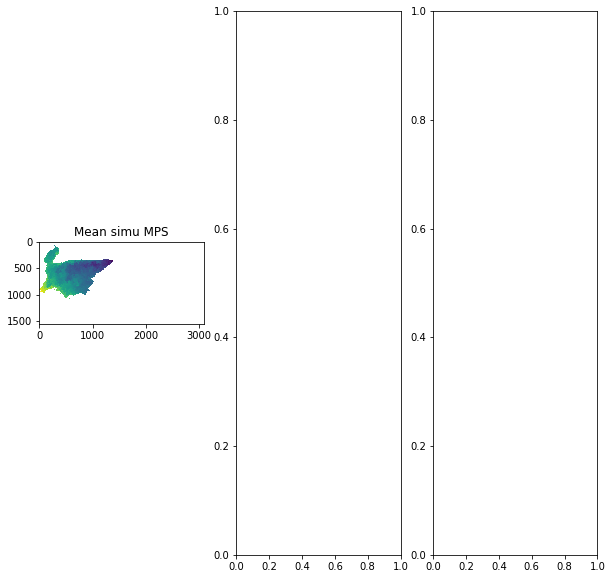

In [137]:
plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(mean_simu_mps)
plt.title('Mean simu MPS')
plt.subplot(1,3,2)
plt.imshow(mean_simu_sgs)
plt.title('Mean simu GRF')
plt.subplot(1,3,3)
plt.imshow(mean_simu_krig)
plt.title('Kriging estimation')
plt.tight_layout()
plt.show()

In [139]:
mean_simu_mps.shape

(1555, 3094)

In [151]:
test = np.full((1200,1400),np.nan)
test[:,:] = mean_simu_mps[:1200,:1400]

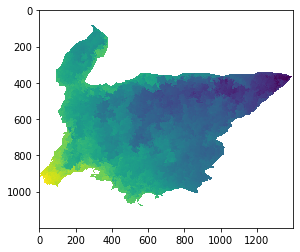

In [152]:
plt.imshow(test)

In [138]:
#Histogramme